# 2016 BCHH infrasound relative-calibration check

Purpose: test whether the relative gains of the colocated BCHH infrasound channels were stable before and after the 1 September 2016 AMOS-6 explosion.

This notebook deliberately starts from the SQLite event catalog and reads waveform data directly from the SDS archive. It does **not** assume that absolute pressure calibration is correct. The primary measurements are pairwise relative gains, robust amplitude ratios, and correlation.

The curated catalog now distinguishes `event_time_utc` from `window_start/window_end`; AMOS-6 is represented as an `explosion` at 2016-09-01 13:07:11.913 UTC.

In [1]:
from pathlib import Path
import sqlite3
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import UTCDateTime, read_inventory
from flovopy.enhanced.sdsclient import EnhancedSDSClient

# Locate repository root whether Jupyter starts there or in 04_event_catalog/.
here = Path.cwd().resolve()
ROOT = next(
    (p for p in [here, *here.parents]
     if (p / "data").exists() and (p / "pyproject.toml").exists()),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate repository root")

DB = ROOT / "data/processed/ksc_rockets.sqlite"
SDS_ROOT = Path("/Volumes/classdata/remastered/SDS_KSC")
XML = Path("/Volumes/classdata/KSC/station_metadata/KSC.xml")

for label, path in {"Database": DB, "SDS": SDS_ROOT, "StationXML": XML}.items():
    print(f"{label}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"{label} not found: {path}")

sds = EnhancedSDSClient(str(SDS_ROOT))
inv = read_inventory(str(XML))


Database: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/KSCRocketSeismology_steps1-3/data/processed/ksc_rockets.sqlite
SDS: /Volumes/classdata/remastered/SDS_KSC
StationXML: /Volumes/classdata/KSC/station_metadata/KSC.xml


## 1. Select events around AMOS-6

Start with the launches immediately before and after the explosion. The date range can be widened later to 3–5 usable events on either side.

In [3]:
START = "2016-07-01T00:00:00Z"
END   = "2016-10-01T00:00:00Z"

with sqlite3.connect(DB) as con:
    events = pd.read_sql_query(
        '''
        SELECT event_id, event_type, event_time_utc, window_start, window_end,
               mission, vehicle, pad, notes
        FROM events
        WHERE event_time_utc >= ? AND event_time_utc < ?
        ORDER BY event_time_utc
        ''',
        con,
        params=(START, END),
    )

#events["event_time"] = pd.to_datetime(events["event_time_utc"], utc=True)
events["event_time"] = pd.to_datetime(
    events["event_time_utc"],
    format="ISO8601",
    utc=True,
)
events


,event_id,event_type,event_time_utc,window_start,window_end,mission,vehicle,pad,notes,event_time
0,ksc-661a5a67e4b2,launch,2016-07-18T04:45:29Z,2016-07-18T04:45:29Z,2016-07-18T04:45:29Z,Falcon 9 Full Thrust | SpX CRS-9,Falcon 9,SLC-40,NaN,2016-07-18 04:45:29+00:00
1,ksc-81cfc0530cc7,launch,2016-07-28T12:00:00Z,2016-07-28T12:00:00Z,2016-07-28T16:00:00Z,Atlas V 421 | NROL-61,Atlas V,SLC-41,NaN,2016-07-28 12:00:00+00:00
2,ksc-2e795d04c05e,launch,2016-08-14T05:26:00Z,2016-08-14T05:26:00Z,2016-08-14T07:26:00Z,Falcon 9 Full Thrust | JCSAT-16,Falcon 9,SLC-40,NaN,2016-08-14 05:26:00+00:00
3,ksc-b391787ae525,launch,2016-08-19T04:47:00Z,2016-08-19T04:47:00Z,2016-08-19T05:52:00Z,"Delta IV M+(4,2) | AFSPC-6",Delta IV,SLC-41,NaN,2016-08-19 04:47:00+00:00
4,ksc-48988fddd1fa,explosion,2016-09-01T13:07:11.913000Z,2016-09-01T13:00:00Z,2016-09-01T14:00:00Z,Falcon 9 Full Thrust | Amos 6 (Failure before ...,Falcon 9,SLC-40,Corrects erroneous 2016-09-03 source row. Wind...,2016-09-01 13:07:11.913000+00:00
5,ksc-ba59e6ac6c4f,launch,2016-09-08T23:05:00Z,2016-09-08T23:05:00Z,2016-09-09T01:05:00Z,Atlas V 411 | OSIRIS-REx,Atlas V,SLC-41,NaN,2016-09-08 23:05:00+00:00


The expected core comparison is JCSAT-16 (14 Aug), AFSPC-6 (19 Aug), AMOS-6 (1 Sep), and OSIRIS-REx (8 Sep). We will let SDS availability decide which events/channels are actually usable.

In [4]:
PRE_S = 30
POST_S = 240

NETWORK = "*"
STATION = "BCHH*"
LOCATION = "*"
CHANNEL = "*D*"  # discovery only

sds = EnhancedSDSClient(str(SDS_ROOT))


In [5]:
def read_event(row):
    t = UTCDateTime(row["event_time_utc"])
    return sds.read(
        starttime=t-PRE_S,
        endtime=t+POST_S,
        net=NETWORK, sta=STATION, loc=LOCATION, chan=CHANNEL,
        skip_low_rate_channels=True,
        merge=None, trim=True, daywise=False,
        postprocess=False, final_smart_merge=False, verbose=False,
    )

availability_rows = []
event_streams = {}

for _, row in events.iterrows():
    try:
        st = read_event(row)
        event_streams[row.event_id] = st
        ids = sorted({tr.id for tr in st})
        print(f"{row.event_time_utc}  {row.mission}")
        print("  " + (", ".join(ids) if ids else "NO CHANNELS FOUND"))
        for tr in st:
            availability_rows.append({
                "event_id": row.event_id,
                "event_time_utc": row.event_time_utc,
                "mission": row.mission,
                "seed_id": tr.id,
                "sampling_rate": float(tr.stats.sampling_rate),
                "npts": int(tr.stats.npts),
            })
    except Exception as exc:
        print(row.event_time_utc, "READ FAILED:", exc)

availability = pd.DataFrame(availability_rows)
availability


2016-07-18T04:45:29Z  Falcon 9 Full Thrust | SpX CRS-9
  NO CHANNELS FOUND
2016-07-28T12:00:00Z  Atlas V 421 | NROL-61
  NO CHANNELS FOUND
2016-08-14T05:26:00Z  Falcon 9 Full Thrust | JCSAT-16
  1R.BCHH.10.DD1, 1R.BCHH.10.DD2, 1R.BCHH.10.DD3, 1R.BCHH.10.DHE, 1R.BCHH.10.DHN, 1R.BCHH.10.DHZ
2016-08-19T04:47:00Z  Delta IV M+(4,2) | AFSPC-6
  1R.BCHH.10.DD1, 1R.BCHH.10.DD2, 1R.BCHH.10.DD3, 1R.BCHH.10.DHE, 1R.BCHH.10.DHN, 1R.BCHH.10.DHZ
2016-09-01T13:07:11.913000Z  Falcon 9 Full Thrust | Amos 6 (Failure before launch)
  1R.BCHH.10.DD1, 1R.BCHH.10.DD2, 1R.BCHH.10.DD3, 1R.BCHH.10.DHE, 1R.BCHH.10.DHN, 1R.BCHH.10.DHZ
2016-09-08T23:05:00Z  Atlas V 411 | OSIRIS-REx
  1R.BCHH.10.DD1, 1R.BCHH.10.DD2, 1R.BCHH.10.DD3, 1R.BCHH.10.DHE, 1R.BCHH.10.DHN, 1R.BCHH.10.DHZ


,event_id,event_time_utc,mission,seed_id,sampling_rate,npts
0,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,1R.BCHH.10.DD1,250.0,67501
1,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,1R.BCHH.10.DD2,250.0,67501
2,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,1R.BCHH.10.DD3,250.0,67501
3,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,1R.BCHH.10.DHE,250.0,67501
4,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,1R.BCHH.10.DHN,250.0,67501
5,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,1R.BCHH.10.DHZ,250.0,67501
6,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",1R.BCHH.10.DD1,250.0,67501
7,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",1R.BCHH.10.DD2,250.0,67501
8,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",1R.BCHH.10.DD3,250.0,67501
9,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",1R.BCHH.10.DHE,250.0,67501


## 2. Response correction

For the relative-calibration test, two complementary calculations are useful:

1. **raw-count relative gain**, which asks whether the acquisition chains changed;
2. **response-corrected relative pressure**, which asks whether the current StationXML makes the channels agree in Pa.

Insert the same StationXML/preprocessing loader used by the ensemble metrics notebook below. Keeping both versions is useful: a change in raw gain but not corrected pressure means the metadata correction is doing its job.

Inventory was loaded and validated in the setup cell. Raw streams are retained unchanged; response-corrected copies are created below.


In [6]:
def common_arrays(tr1, tr2):
    # Align by actual sample time, not merely by equal array length.
    sr1 = float(tr1.stats.sampling_rate)
    sr2 = float(tr2.stats.sampling_rate)
    if not np.isclose(sr1, sr2, rtol=0, atol=1e-8):
        raise ValueError(f"Sampling rates differ: {sr1} vs {sr2}")

    sr = sr1
    t0 = max(tr1.stats.starttime, tr2.stats.starttime)
    t1 = min(tr1.stats.endtime, tr2.stats.endtime)
    if t1 <= t0:
        return np.array([]), np.array([])

    i1 = int(round((t0-tr1.stats.starttime)*sr))
    i2 = int(round((t0-tr2.stats.starttime)*sr))
    n = min(int(np.floor((t1-t0)*sr))+1,
            tr1.stats.npts-i1, tr2.stats.npts-i2)
    if n <= 0:
        return np.array([]), np.array([])

    x = np.asarray(tr1.data[i1:i1+n], dtype=float)
    y = np.asarray(tr2.data[i2:i2+n], dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    return x[good], y[good]

def pair_metrics(tr1, tr2):
    x, y = common_arrays(tr1, tr2)
    if len(x) < 10:
        return {}

    x = x - np.median(x)
    y = y - np.median(y)

    rms = lambda z: np.sqrt(np.mean(z*z))
    p99 = lambda z: np.percentile(np.abs(z), 99)

    denom = np.dot(y, y)
    slope = np.dot(y, x)/denom if denom > 0 else np.nan

    return {
        "slope": slope,  # tr1 ~= slope * tr2
        "rms_ratio": rms(x)/rms(y) if rms(y) > 0 else np.nan,
        "p99_ratio": p99(x)/p99(y) if p99(y) > 0 else np.nan,
        "peak_ratio": np.max(np.abs(x))/np.max(np.abs(y))
                      if np.max(np.abs(y)) > 0 else np.nan,
        "correlation": np.corrcoef(x,y)[0,1]
                       if np.std(x) > 0 and np.std(y) > 0 else np.nan,
        "npts": len(x),
    }


## 3. Compute pairwise gains

After the trace-ID inspection above, set `PRESSURE_IDS` to the three actual BCHH infrasound channels for this epoch. If sensor serial numbers changed across these dates, retain that information explicitly rather than assuming channel number = sensor identity.

In [8]:
PRESSURE_IDS = [
    "1R.BCHH.10.DD1",
    "1R.BCHH.10.DD2",
    "1R.BCHH.10.DD3",
]

present = set(availability["seed_id"]) if not availability.empty else set()
for seed_id in PRESSURE_IDS:
    if seed_id not in present:
        print("WARNING: not found in discovery interval:", seed_id)

def select_ids(st, ids=PRESSURE_IDS):
    out = {}
    for seed_id in ids:
        matches = [tr.copy() for tr in st if tr.id == seed_id]
        if len(matches) == 1:
            out[seed_id] = matches[0]
        elif len(matches) > 1:
            print(f"WARNING: {seed_id} has {len(matches)} segments; skipping")
    return out

def compute_pair_table(streams, domain):
    rows = []
    lookup = events.set_index("event_id")
    for event_id, st in streams.items():
        if event_id not in lookup.index:
            continue
        event = lookup.loc[event_id]
        traces = select_ids(st)
        for id1, id2 in combinations(PRESSURE_IDS, 2):
            if id1 not in traces or id2 not in traces:
                continue
            m = pair_metrics(traces[id1], traces[id2])
            if m:
                rows.append({
                    "event_id": event_id,
                    "event_time_utc": event.event_time_utc,
                    "mission": event.mission,
                    "event_type": event.event_type,
                    "pair": f"{id1} / {id2}",
                    "domain": domain,
                    **m,
                })
    df = pd.DataFrame(rows)
    if not df.empty:
        #df["event_time"] = pd.to_datetime(df["event_time_utc"], utc=True)
        df["event_time"] = pd.to_datetime(
            df["event_time_utc"],
            format="ISO8601",
            utc=True,
        )
    return df

raw_relative = compute_pair_table(event_streams, "raw_counts")
raw_relative


,event_id,event_time_utc,mission,event_type,pair,domain,slope,rms_ratio,p99_ratio,peak_ratio,correlation,npts,event_time
0,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,raw_counts,2.518113,40.653434,26.213483,10.915194,0.063749,67501,2016-08-14 05:26:00+00:00
1,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,raw_counts,-0.027011,2.860734,1.771450,0.773410,-0.009418,67501,2016-08-14 05:26:00+00:00
2,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,launch,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,raw_counts,0.008317,0.070369,0.067578,0.070856,0.119130,67501,2016-08-14 05:26:00+00:00
3,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,raw_counts,27.271961,42.144031,59.285714,63.339623,0.677285,67501,2016-08-19 04:47:00+00:00
4,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,raw_counts,10.403839,93.858264,103.750000,76.295455,0.133328,67501,2016-08-19 04:47:00+00:00
5,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",launch,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,raw_counts,1.213613,2.227083,1.750000,1.204545,0.541786,67501,2016-08-19 04:47:00+00:00
6,ksc-48988fddd1fa,2016-09-01T13:07:11.913000Z,Falcon 9 Full Thrust | Amos 6 (Failure before ...,explosion,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,raw_counts,17.396044,49.362434,77.666667,10.176417,0.365370,67501,2016-09-01 13:07:11.913000+00:00
7,ksc-48988fddd1fa,2016-09-01T13:07:11.913000Z,Falcon 9 Full Thrust | Amos 6 (Failure before ...,explosion,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,raw_counts,-0.021282,3.063680,3.174387,0.764839,-0.023146,67501,2016-09-01 13:07:11.913000+00:00
8,ksc-48988fddd1fa,2016-09-01T13:07:11.913000Z,Falcon 9 Full Thrust | Amos 6 (Failure before ...,explosion,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,raw_counts,0.026826,0.062065,0.040872,0.075158,0.462992,67501,2016-09-01 13:07:11.913000+00:00
9,ksc-ba59e6ac6c4f,2016-09-08T23:05:00Z,Atlas V 411 | OSIRIS-REx,launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,raw_counts,0.686675,88.221054,42.707692,19.108374,0.006058,67501,2016-09-08 23:05:00+00:00


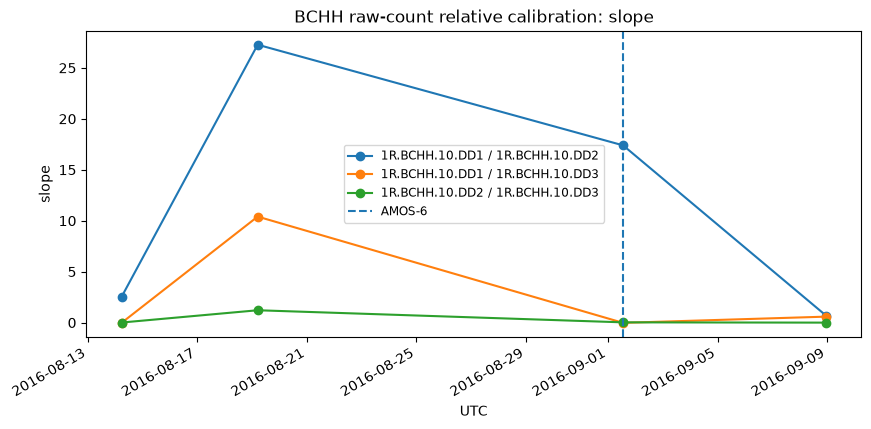

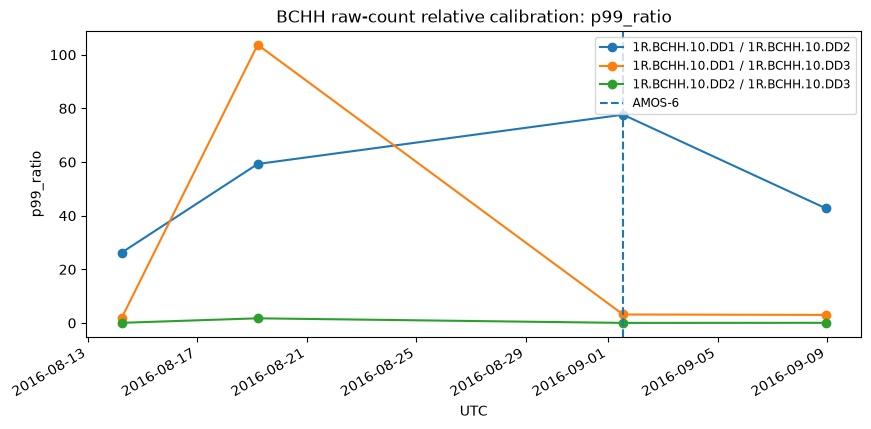

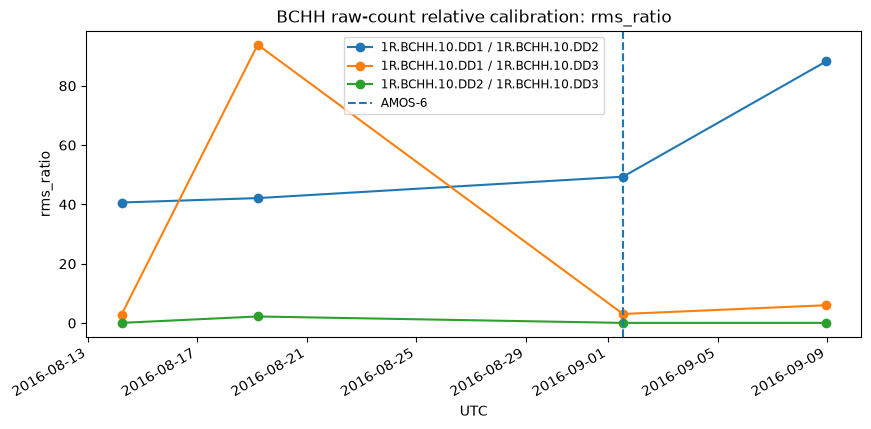

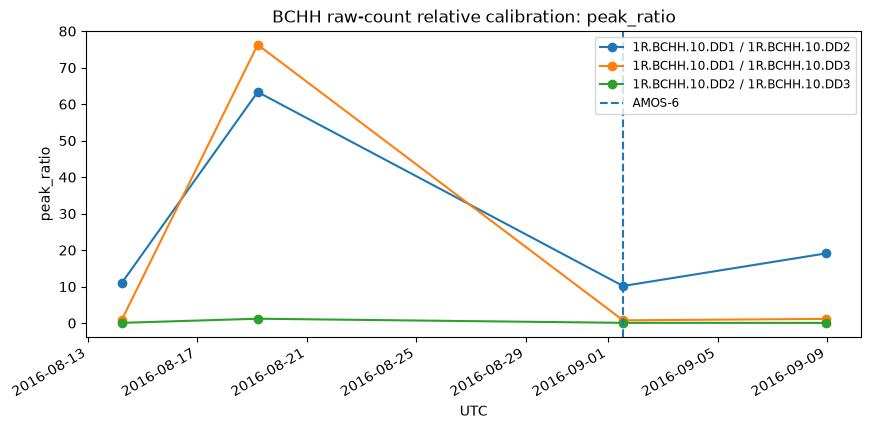

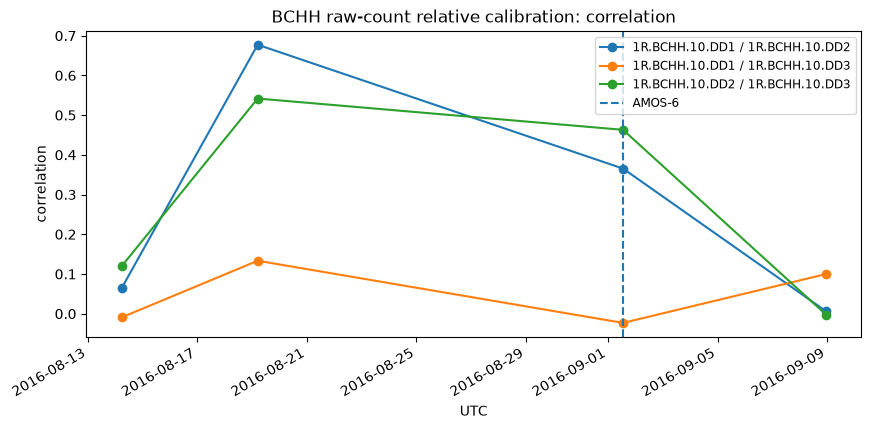

In [9]:
AMOS6_TIME = pd.Timestamp("2016-09-01T13:07:11.913Z")

def plot_metric(df, metric, title_prefix):
    if df.empty:
        print("No data:", title_prefix, metric)
        return
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for pair, g in df.groupby("pair"):
        g = g.sort_values("event_time")
        ax.plot(g.event_time, g[metric], marker="o", label=pair)
    ax.axvline(AMOS6_TIME, linestyle="--", label="AMOS-6")
    ax.set_ylabel(metric)
    ax.set_xlabel("UTC")
    ax.set_title(f"{title_prefix}: {metric}")
    ax.legend(fontsize="small")
    fig.autofmt_xdate()
    plt.show()

for metric in ["slope", "p99_ratio", "rms_ratio", "peak_ratio", "correlation"]:
    plot_metric(raw_relative, metric, "BCHH raw-count relative calibration")


## 4. Interpretation checklist

- Do pairwise slopes/ratios remain constant across 1 September?
- Does any step follow a **sensor serial number** or a channel/acquisition path?
- Are ratios stable for ordinary launches but distorted during AMOS-6 because of clipping/non-linearity?
- Do raw-count ratios and response-corrected Pa ratios tell the same story?
- Repeat using moderate-amplitude portions of AMOS-6 if the strongest impulses approach clipping.
- Once stable, write the resulting relative-calibration/QC conclusion back to the station/channel epoch metadata rather than applying an undocumented correction in this notebook.

## 4. Response-corrected comparison

Now repeat the same pairwise test after applying the current StationXML to **copies** of the traces. This distinguishes stability of the raw acquisition chains from agreement after the response metadata are applied.

The response-removal corners below are provisional and should be reviewed against the 2016 sensor responses and signal/noise spectra before publication.


In [10]:
PRE_FILT = (0.1, 0.2, 40.0, 45.0)
WATER_LEVEL = 60

corrected_streams = {}
response_rows = []

for event_id, st in event_streams.items():
    corrected = st.__class__()
    for tr in st:
        if tr.id not in PRESSURE_IDS:
            continue
        trc = tr.copy()
        try:
            trc.detrend("linear")
            trc.detrend("demean")
            trc.taper(max_percentage=0.05, type="cosine")
            trc.remove_response(
                inventory=inv, output="DEF",
                pre_filt=PRE_FILT, water_level=WATER_LEVEL,
                zero_mean=False, taper=False,
            )
            trc.stats.units = "Pa"
            corrected.append(trc)
            response_rows.append(
                {"event_id":event_id, "seed_id":tr.id,
                 "response_ok":True, "error":None}
            )
        except Exception as exc:
            response_rows.append(
                {"event_id":event_id, "seed_id":tr.id,
                 "response_ok":False, "error":str(exc)}
            )
    corrected_streams[event_id] = corrected

response_status = pd.DataFrame(response_rows)
response_status


,event_id,seed_id,response_ok,error
0,ksc-2e795d04c05e,1R.BCHH.10.DD1,True,None
1,ksc-2e795d04c05e,1R.BCHH.10.DD2,True,None
2,ksc-2e795d04c05e,1R.BCHH.10.DD3,True,None
3,ksc-b391787ae525,1R.BCHH.10.DD1,True,None
4,ksc-b391787ae525,1R.BCHH.10.DD2,True,None
5,ksc-b391787ae525,1R.BCHH.10.DD3,True,None
6,ksc-48988fddd1fa,1R.BCHH.10.DD1,True,None
7,ksc-48988fddd1fa,1R.BCHH.10.DD2,True,None
8,ksc-48988fddd1fa,1R.BCHH.10.DD3,True,None
9,ksc-ba59e6ac6c4f,1R.BCHH.10.DD1,True,None


In [11]:
pa_relative = compute_pair_table(corrected_streams, "response_corrected_Pa")
pa_relative


,event_id,event_time_utc,mission,event_type,pair,domain,slope,rms_ratio,p99_ratio,peak_ratio,correlation,npts,event_time
0,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,response_corrected_Pa,-0.308826,14.030774,9.858018,8.719419,-0.021996,67501,2016-08-14 05:26:00+00:00
1,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,response_corrected_Pa,0.000640,0.928690,0.650989,0.649954,0.000690,67501,2016-08-14 05:26:00+00:00
2,ksc-2e795d04c05e,2016-08-14T05:26:00Z,Falcon 9 Full Thrust | JCSAT-16,launch,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,response_corrected_Pa,0.024195,0.066190,0.066036,0.074541,0.365543,67501,2016-08-14 05:26:00+00:00
3,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,response_corrected_Pa,-30.298123,232.349616,242.861242,316.571178,-0.130530,67501,2016-08-19 04:47:00+00:00
4,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,response_corrected_Pa,1.430870,56.492372,60.930358,72.320405,0.025334,67501,2016-08-19 04:47:00+00:00
5,ksc-b391787ae525,2016-08-19T04:47:00Z,"Delta IV M+(4,2) | AFSPC-6",launch,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,response_corrected_Pa,-0.008182,0.243135,0.250885,0.228449,-0.033635,67501,2016-08-19 04:47:00+00:00
6,ksc-48988fddd1fa,2016-09-01T13:07:11.913000Z,Falcon 9 Full Thrust | Amos 6 (Failure before ...,explosion,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,response_corrected_Pa,4.242346,14.245475,22.898194,10.098805,0.297804,67501,2016-09-01 13:07:11.913000+00:00
7,ksc-48988fddd1fa,2016-09-01T13:07:11.913000Z,Falcon 9 Full Thrust | Amos 6 (Failure before ...,explosion,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,response_corrected_Pa,0.316193,0.963925,1.147022,0.751774,0.328074,67501,2016-09-01 13:07:11.913000+00:00
8,ksc-48988fddd1fa,2016-09-01T13:07:11.913000Z,Falcon 9 Full Thrust | Amos 6 (Failure before ...,explosion,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,response_corrected_Pa,0.053207,0.067665,0.050092,0.074442,0.786489,67501,2016-09-01 13:07:11.913000+00:00
9,ksc-ba59e6ac6c4f,2016-09-08T23:05:00Z,Atlas V 411 | OSIRIS-REx,launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,response_corrected_Pa,-0.597332,19.494237,13.288543,18.466598,-0.030639,67501,2016-09-08 23:05:00+00:00


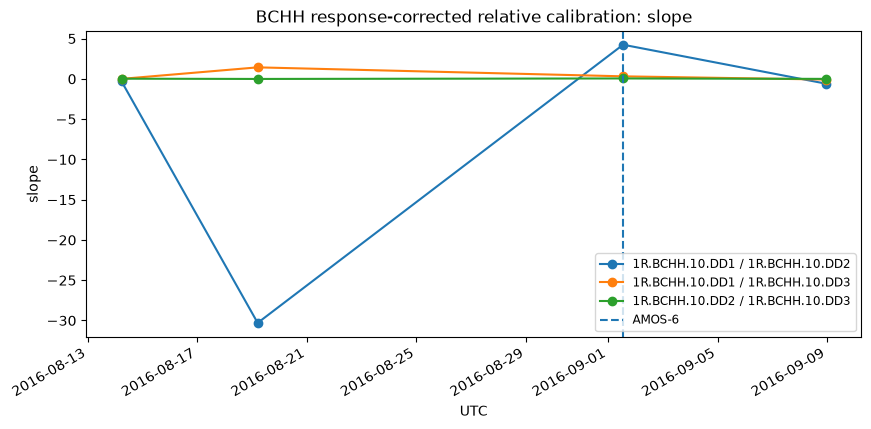

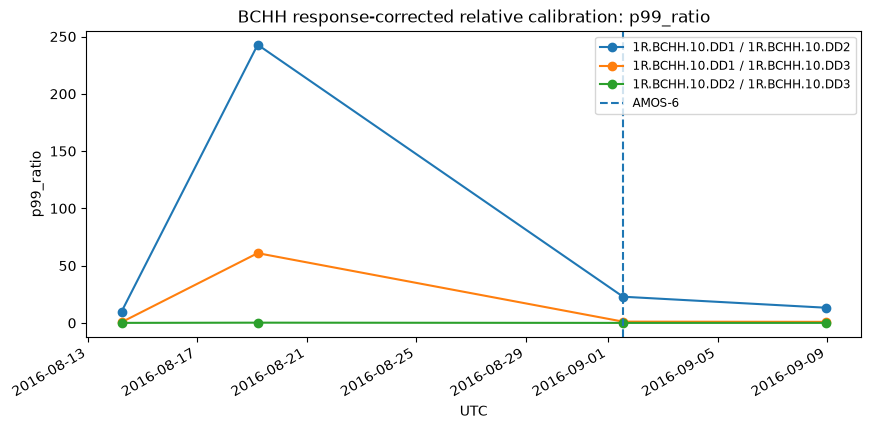

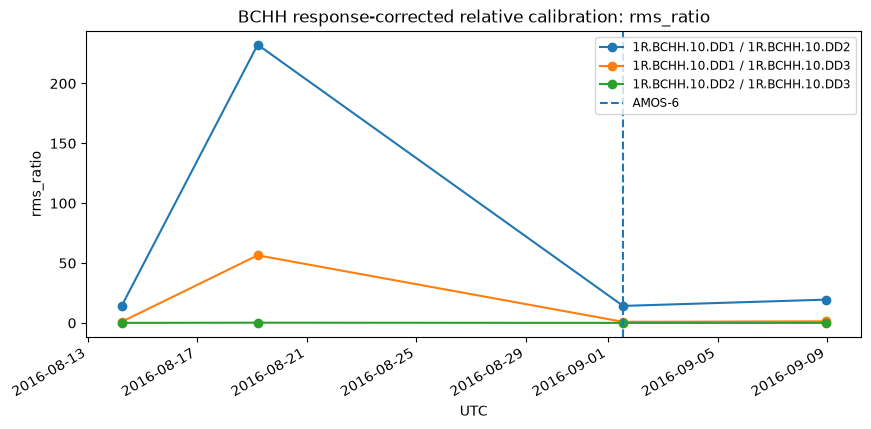

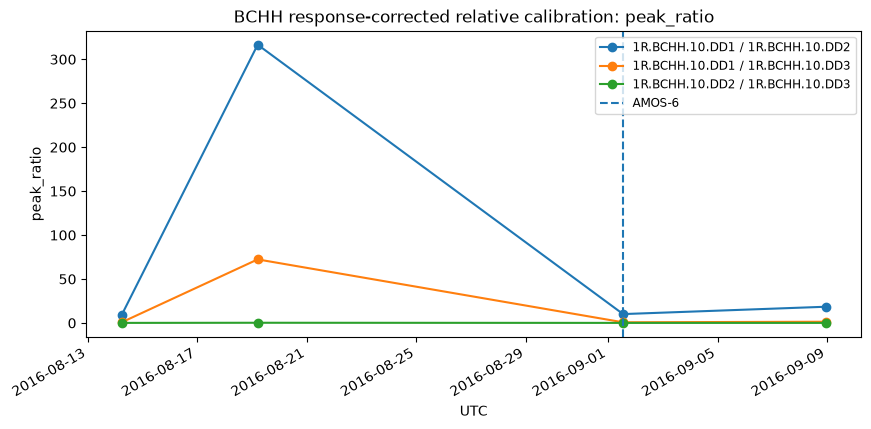

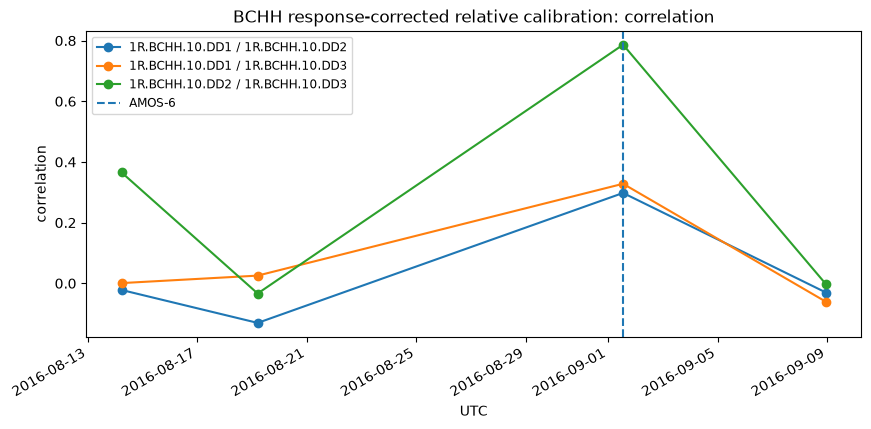

In [12]:
for metric in ["slope", "p99_ratio", "rms_ratio", "peak_ratio", "correlation"]:
    plot_metric(pa_relative, metric, "BCHH response-corrected relative calibration")


## 5. Interpretation

The regression slope and p99 ratio are the main diagnostics; peak ratio is more vulnerable to spikes and clipping.

Before calling any step a sensor-calibration change:

- identify the **sensor serial number** behind each NSLC for every event;
- inspect whether AMOS-6 clipped or drove any channel nonlinear;
- check timing and polarity;
- compare pre-event ambient/noise intervals as an independent stability check;
- if AMOS-6 is nonlinear, repeat its calculation using moderate-amplitude portions only;
- determine whether any inferred change follows a sensor, digitizer/channel path, or metadata epoch.

A particularly useful diagnostic is disagreement between the two domains: if raw-count ratios change but corrected-Pa ratios do not, the response metadata may already encode the gain change. If corrected-Pa ratios step while raw-count ratios remain stable, the StationXML deserves scrutiny.
